# J-lens vs logit lens on GPT-2 XL — shared-activation dataset evaluation

Based on `notebooks/logit_lens/logit_lens_dataset.ipynb`, retaining every metric and diagnostic
across all six evaluation sets. For each prompt, **one forward pass** records the pre-`ln_f`
output of every block. The logit lens reads `unembed(h_l)`; the J-lens reads
`unembed(J_l @ h_l)`. Both use the same activations, tokenization, readout position, controls,
and exact final model logits. The final row is identical; compare inner layers separately.

Load a fitted lens for the selected model, or fit one on an independent mixed corpus below.
Results retain a `lens` column throughout; model accuracy is counted once per item.

**Protocol** (`data/evaluations/README.md`):

* **readout position** — one token per prompt: the last prompt token (the one right before `target`,
  the closing period, the tail of the typo); for poetry — the newline at the end of the first line;
* **rank** — 1-based rank of a word among all 50 257 tokens at that position, min over its single-token
  spellings (with/without leading space, case); for order-ops — min over the synonym set
  (numbers → digits and words, operations → symbols and words); multi-token words fall back to their first token;
* **pass@k** — mean over items of the fraction of `intermediates` whose min-over-layers rank ≤ k;
* **control** — the same ranks for the intermediates of *another* item of the same dataset.
  It is the chance level: a lens that surfaces any vaguely topical word scores here too.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# ноутбук открыт из клона репозитория (notebooks/<lens>/) — ищем его корень выше по дереву
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "gpt2" / "lens_eval.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

Cloning into '/content/jacobian-lens-gpt2'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 159 (delta 61), reused 82 (delta 35), pack-reused 38 (from 1)
Receiving objects: 100% (159/159), 3.79 MiB | 8.77 MiB/s, done.
Resolving deltas: 100% (63/63), done.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import jlens
from jlens import benchmark_dim_batches
from gpt2 import GPT2LensModel
from gpt2.lens_eval import (
    DATASETS,
    FIT_MIX,
    ROLE_NAMES,
    evaluate_paired,
    first_layer,
    fit_with_progress,
    identity_lens,
    layer_hit_rate,
    layer_mean,
    layer_median_rank,
    load_eval,
    load_fit_prompts,
    pass_at_k,
    plot_layer_curves,
    shown_layers,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"  # 1.5B parameters, 48 layers, d_model 1600
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

gpt = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
LENS_NAMES = ("logit lens", "J-lens")
LAYER_STRIDE = 4
assert gpt.n_layers >= 2, "The inner-layer comparison needs at least two layers."
gpt

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 6.43GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

GPT2LensModel(n_layers=48, d_model=1600)

In [4]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}

K = 10
KS = sorted({1, 5, 10, 100, K})
LAST = gpt.n_layers - 1
{dataset: len(samples) for dataset, samples in evals.items()}

{'multihop': 93,
 'multilingual': 107,
 'order-ops': 55,
 'poetry': 98,
 'association': 102,
 'typo': 96}

## Load or fit the J-lens

Set `LENS_PATH` to an existing `JacobianLens.save` file fitted for **this model and all its
inner layers** (e.g. the checkpoint saved by `jacobian_lens.ipynb`). A fit-resume checkpoint
is a different format. Width and layer coverage are checked, but a saved lens does not
record its model ID, so choosing the matching model is necessary.

When the file is absent, stream a mixed corpus using `FIT_MIX`, fit the Jacobians, and save
them. Evaluation prompts are not used for fitting. Loading an existing file skips corpus
downloads. GPT-2 XL fitting is expensive: tune `FIT_FRACTION`, `DIM_BATCH`, and `MAX_SEQ_LEN`
for your hardware, or use a smaller `MODEL_ID`. Resuming requires the same prompt list.

### Fit prompt batches on one GPU

`FIT_MODE="batched"` uses the already-loaded model to compute several prompts together.
`PROMPT_BATCH_SIZE` is the number of different prompts; `DIM_BATCH` is the number of
Jacobian output dimensions computed per prompt in each backward pass. The physical
model batch is their product: the CUDA defaults of 2 and 32 create 64 sequences in one
forward graph, followed by `ceil(d_model / DIM_BATCH)` backward passes per prompt batch.
Adjust both settings to your GPU and model; these defaults have not been benchmarked
on an A100. `FIT_MODE="single"` retains the original one-prompt fitting path.

Each disjoint prompt batch produces a `JacobianLens`. The fitter calls the original
**`JacobianLens.merge`** to combine it with the running lens, weighted by successful
prompt counts. Variable-length prompts are right-padded; padding, early positions,
and each prompt's final position are excluded from the Jacobian estimator. Short
prompts are skipped. Partial batches receive the correct weight.

Progress shows forward/backward phases and processed prompt counts. Checkpoints are
written every five **batches**, retain the merged lens and next prompt index, and verify
model ID, adapter, dtype, prompts, and fit settings on resume. Batched checkpoints use a
separate path from older serial or process-shard checkpoints. Loading a final `LENS_PATH`
skips fitting; choose a new final path when comparing fitting settings.

`BENCHMARK_DIM_BATCHES` optionally times a complete **single-prompt** Jacobian for each
candidate dimension batch. Prompt batching multiplies its activation memory, so tune
`PROMPT_BATCH_SIZE` using actual batched runs as well. Evaluation metrics still use the
same activations for both lenses.


In [5]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
torch.set_float32_matmul_precision("high")

In [7]:
LENS_PATH = (
       Path("/content/drive/MyDrive/jacobian-lens")
       / f"{MODEL_ID.split('/')[-1]}_jacobian_lens_dataset.pt"
)
FIT_FRACTION = 0.25
MAX_SEQ_LEN = 128
FIT_MODE = "single"  # "batched" or "single", using the same loaded model
PROMPT_BATCH_SIZE = 2  # different prompts computed together on one GPU
DIM_BATCH = 32 if DEVICE == "cuda" else 4  # output dimensions per prompt/backward
BENCHMARK_DIM_BATCHES = False  # optional single-prompt Jacobian timing

assert FIT_MODE in ("single", "batched")
if LENS_PATH.is_file():
    fitted_lens = jlens.JacobianLens.load(str(LENS_PATH))
else:
    LENS_PATH.parent.mkdir(parents=True, exist_ok=True)
    fit_mix = {source: max(1, round(n * FIT_FRACTION)) for source, n in FIT_MIX.items()}
    fit_prompts = load_fit_prompts(fit_mix, seed=0)
    display(fit_prompts.source.value_counts().to_frame("prompts"))
    print(f"Fit mode: {FIT_MODE}; corpus: {len(fit_prompts)} prompts", flush=True)
    if BENCHMARK_DIM_BATCHES:
        display(pd.DataFrame(benchmark_dim_batches(
            gpt, fit_prompts.text.iloc[0], candidates=(8, 16, 32), max_seq_len=MAX_SEQ_LEN
        )))
    if FIT_MODE == "batched":
        checkpoint_path = LENS_PATH.with_name(
            LENS_PATH.stem + f"_prompts{PROMPT_BATCH_SIZE}_dim{DIM_BATCH}_seq{MAX_SEQ_LEN}_ckpt.pt"
        )
        fitted_lens = jlens.fit_batched(
            gpt,
            fit_prompts.text.tolist(),
            model_id=MODEL_ID,
            prompt_batch_size=PROMPT_BATCH_SIZE,
            dim_batch=DIM_BATCH,
            max_seq_len=MAX_SEQ_LEN,
            checkpoint_path=checkpoint_path,
            checkpoint_every=5,
        )
    else:
        fitted_lens = fit_with_progress(
            gpt,
            fit_prompts.text.tolist(),
            dim_batch=DIM_BATCH,
            max_seq_len=MAX_SEQ_LEN,
            checkpoint_path=str(LENS_PATH.with_name(LENS_PATH.stem + "_ckpt.pt")),
            checkpoint_every=5,
        )
    fitted_lens.save(str(LENS_PATH))

assert fitted_lens.d_model == gpt.d_model
assert set(range(LAST)).issubset(fitted_lens.source_layers)
fitted_lens


fit corpus:   0%|          | 0/134 [00:00<?, ?prompt/s]

README.md:   0%|          | 0.00/44.3k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/27468 [00:00<?, ?it/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

...

,prompts
source,
web,38
math,15
dialogue,15
wikipedia,15
fiction,15
code,10
poetry,10
french,4
portuguese,4


Fit mode: single; corpus: 134 prompts


fit J-lens:   0%|          | 0/134 [00:00<?, ?prompt/s]

INFO:jlens.fitting:fit: n_layers=48 d_model=1600, fitting 47 source layers (target=L47) on 134 prompts
INFO:jlens.fitting:  jacobian forward: seq_len=128 dim_batch=32 backward_passes=50
INFO:jlens.fitting:  jacobian backward: 1/50
INFO:jlens.fitting:  jacobian backward: 10/50
INFO:jlens.fitting:  jacobian backward: 19/50
INFO:jlens.fitting:  jacobian backward: 28/50
INFO:jlens.fitting:  jacobian backward: 37/50
INFO:jlens.fitting:  jacobian backward: 46/50
INFO:jlens.fitting:  jacobian backward: 50/50
INFO:jlens.fitting:  prompt 1/134  seq_len=128 n_valid=111  14s  max||J||/sqrt(d)=1.461  max_d_mean=nan
INFO:jlens.fitting:  jacobian forward: seq_len=128 dim_batch=32 backward_passes=50
INFO:jlens.fitting:  jacobian backward: 1/50
INFO:jlens.fitting:  jacobian backward: 10/50
INFO:jlens.fitting:  jacobian backward: 19/50
INFO:jlens.fitting:  jacobian backward: 28/50
INFO:jlens.fitting:  jacobian backward: 37/50
INFO:jlens.fitting:  jacobian backward: 46/50
INFO:jlens.fitting:  jacobian b

JacobianLens(d_model=1600, n_prompts=134, source_layers=[0..46] (47 layers))

### Identity sanity check

With `J_l = I`, both readouts must produce the same ranks, best layers, top-1 tokens,
agreement, copy rate, and KL. This small check uses the same paired evaluator as the full run.

In [12]:
from jlens.evaluation import load_eval

sanity_records = load_eval(REPO_DIR, "order-ops")
sanity_evals = {"order-ops": sanity_records[:2]}
previous_precision = torch.get_float32_matmul_precision()

try:
    torch.set_float32_matmul_precision("highest")
    with torch.autocast(device_type=gpt.input_device.type, enabled=False):
        sanity_words, sanity_items = evaluate_paired(
            gpt, identity_lens(gpt), sanity_evals,
            desc="identity check",
        )

    for frame in (sanity_words, sanity_items):
        left = (
            frame[frame.lens == "logit lens"]
            .drop(columns="lens").reset_index(drop=True)
        )
        right = (
            frame[frame.lens == "J-lens"]
            .drop(columns="lens").reset_index(drop=True)
        )
        pd.testing.assert_frame_equal(left, right)
finally:
    torch.set_float32_matmul_precision(previous_precision)

print("Identity lens: all metrics match.")

identity check:   0%|          | 0/1 [00:00<?, ?it/s]

order-ops:   0%|          | 0/2 [00:00<?, ?it/s]

Identity lens: all metrics match.


## 1. Run

`words` — a row per (lens, item, word) with the rank at every layer; `items` — a row per
(lens, item) with the model answer, readout top-1 tokens, and per-layer statistics over all
prompt positions. `evaluate_paired` records activations once per prompt and reads each lens
sequentially, releasing vocabulary logits after collecting its metrics. It does not cache
activations or logits across the dataset.

In [13]:
words, items = evaluate_paired(gpt, fitted_lens, evals)
words["inner_best"] = [int(r[:-1].min()) for r in words.ranks]
words["inner_best_layer"] = [int(r[:-1].argmin()) for r in words.ranks]

# The final row and model answers must agree for every paired item/word.
word_keys = ["dataset", "item", "kind", "word", "role"]
final_ranks = words.assign(final_rank=[int(r[-1]) for r in words.ranks]).pivot(
    index=word_keys, columns="lens", values="final_rank"
)
assert (final_ranks["logit lens"] == final_ranks["J-lens"]).all()
for column in ("model_top1", "model_correct", "readout_token"):
    paired = items.pivot(index=["dataset", "item"], columns="lens", values=column)
    pd.testing.assert_series_equal(paired["logit lens"], paired["J-lens"], check_names=False)
for name in LENS_NAMES:
    frame = items[items.lens == name]
    np.testing.assert_allclose(np.stack(frame.agreement)[:, -1], 1)
    np.testing.assert_allclose(np.stack(frame.kl_to_final)[:, -1], 0, atol=1e-6)
print("Final model readout matches for both lenses.")

paired lenses:   0%|          | 0/6 [00:00<?, ?it/s]

multihop:   0%|          | 0/93 [00:00<?, ?it/s]

multilingual:   0%|          | 0/107 [00:00<?, ?it/s]

order-ops:   0%|          | 0/55 [00:00<?, ?it/s]

poetry:   0%|          | 0/98 [00:00<?, ?it/s]

association:   0%|          | 0/102 [00:00<?, ?it/s]

typo:   0%|          | 0/96 [00:00<?, ?it/s]

Final model readout matches for both lenses.


In [14]:
words.head()

,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens,inner_best,inner_best_layer
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[8694, 8600, 8408, 11385, 11840, 14797, 16763,...",4428,45,logit lens,4428,45
1,multihop,carnival-ocean,control,China,0,True,False,"[3191, 4428, 5774, 7387, 9202, 11075, 13775, 1...",3191,0,logit lens,3191,0
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[2433, 2459, 2089, 2822, 2981, 3145, 2477, 343...",53,37,logit lens,53,37
3,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[845, 1628, 6630, 13142, 14744, 7023, 5648, 69...",845,0,J-lens,845,0
4,multihop,carnival-ocean,control,China,0,True,False,"[1667, 2380, 10401, 25132, 19782, 17252, 11807...",1667,0,J-lens,1667,0


In [15]:
items.head()

,dataset,item,prompt,target,readout_token,model_top1,model_correct,readout_top1,agreement,copy_rate,kl_to_final,lens
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,most,False,"[ rest, same, most, most, most, most, sa...","[0.055555556, 0.11111111, 0.22222222, 0.277777...","[0.2777778, 0.055555556, 0.055555556, 0.055555...","[4.6780734, 4.1358194, 3.8898401, 3.7101288, 3...",logit lens
1,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,most,False,"[ , ‎, ', ', ', ', ..., \n\n, \n\n, \n\n...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2777778, 0.22222222, 0.22222222, 0.22222222...","[7.952708, 9.722194, 10.666015, 10.453903, 8.4...",J-lens
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,not,False,"[ not, not, not, not, not, not, likely, ...","[0.071428575, 0.071428575, 0.071428575, 0.2142...","[0.14285715, 0.071428575, 0.071428575, 0.07142...","[4.311619, 3.8314679, 3.6151211, 3.528351, 3.5...",logit lens
3,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,not,False,"[\n, ­, —, Polk, —, —, \n\n, \n\n, \n\n, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.35714287, 0.2857143, 0.21428573, 0.21428573...","[6.2238436, 8.379977, 9.599227, 8.8563, 7.0257...",J-lens
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,is,not,False,"[ meant, not, supposed, not, not, suppose...","[0.0, 0.083333336, 0.0, 0.16666667, 0.16666667...","[0.083333336, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[4.6532416, 4.302684, 4.1607537, 3.8925476, 3....",logit lens


In [16]:
inter = words[words.kind == "intermediate"]
control = words[words.kind == "control"]
target = words[words.kind == "target"]

## 2. Can GPT-2 XL solve the tasks at all?

The lens can only show an intermediate step the model actually computes. For the three sets with a `target`,
check whether the model's own top-1 at the readout position is the target.

In [17]:
model_items = items.drop_duplicates(["dataset", "item"])
with_target = model_items.dropna(subset=["model_correct"]).astype({"model_correct": bool})
accuracy = with_target.groupby("dataset").model_correct.mean()
accuracy.to_frame("model top-1 == target")

,model top-1 == target
dataset,
multihop,0.075269
multilingual,0.037383
order-ops,0.018182


In [18]:
with_target.groupby("dataset").head(6)[["dataset", "item", "prompt", "target", "model_top1", "model_correct"]]

,dataset,item,prompt,target,model_top1,model_correct
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,most,False
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,not,False
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,not,False
6,multihop,spider-legs,Fact: The number of legs on the animal that sp...,8,the,False
8,multihop,basketball-players,Fact: The number of players per side in the sp...,5,about,False
10,multihop,paper-continent,Fact: The continent where the country that inv...,Asia,the,False
186,multilingual,spanish-opposite-big,"Lo opuesto de ""grande"" es """,pequeño,grand,False
188,multilingual,french-season-summer,La saison après l'été est l',automne,é,False
190,multilingual,german-opposite-loud,Das Gegenteil von laut ist,leise,e,False
192,multilingual,chinese-color-banana,"""香蕉""的颜色是""",黄,�,False


## 3. pass@k: intermediates vs control vs target

In [19]:
scores = pass_at_k(words, ks=KS)
scores.pivot_table(index="dataset", columns=["kind", "k", "lens"], values="score").round(3)

kind         control                                                                  intermediate                                                                  target                                                                 
k                1                 5                 10                100                     1                 5                 10                100               1                 5                 10                100           
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens       J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                                                                                                                                                                                    
association    0.000      0.000  0.010      0.000  0.010      0.000  0.098      0.049        0.020      0.010  0.029      0.020  0.049      0.039  0.167      0.137    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
multihop       0.000      0.000  0.011      0.033  0.033      0.069  0.221      0.226        0.108      0.097  0.204      0.204  0.301      0.280  0.611      0.597  0.151      0.172  0.366      0.376  0.462      0.505  0.925      0.871
multilingual   0.002      0.005  0.007      0.023  0.009      0.040  0.118      0.228        0.044      0.061  0.119      0.140  0.157      0.185  0.299      0.411  0.056      0.056  0.131      0.196  0.187      0.215  0.598      0.551
order-ops      0.040      0.040  0.240      0.310  0.510      0.490  0.990      0.980        0.091      0.091  0.427      0.373  0.764      0.600  1.000      0.982  0.073      0.073  0.418      0.564  0.764      0.836  1.000      1.000
poetry         0.000      0.000  0.000      0.010  0.000      0.010  0.153      0.184        0.000      0.000  0.000      0.000  0.000      0.010  0.255      0.214    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
typo           0.000      0.000  0.000      0.000  0.000      0.021  0.052      0.083        0.198      0.104  0.365      0.240  0.406      0.323  0.812      0.740    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN

The min over layers includes the last row — the model's own output. Split it: what do the inner layers (all but the last)
show that the output does not?

In [20]:
inner = pass_at_k(words, ks=KS, layers=slice(None, -1)).assign(readout=f"layers 0..{LAST - 1}")
output = pass_at_k(words, ks=KS, layers=[LAST]).assign(readout="model output")
split = pd.concat([inner, output], ignore_index=True)
split[split.k == K].pivot_table(index="dataset", columns=["kind", "readout", "lens"], values="score").round(3)

kind              control                                    intermediate                                          target                                   
readout      layers 0..46            model output            layers 0..46            model output            layers 0..46            model output           
lens               J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens
dataset                                                                                                                                                     
association         0.010      0.000        0.000      0.000        0.049      0.039        0.000      0.000          NaN        NaN          NaN        NaN
multihop            0.022      0.069        0.022      0.022        0.280      0.280        0.172      0.172        0.387      0.505        0.366      0.366
multilingual        0.009      0.040        0.000      0.000        0.157      0.185        0.016      0.016        0.178      0.215        0.093      0.093
order-ops           0.470      0.490        0.170      0.170        0.709      0.582        0.318      0.318        0.691      0.836        0.600      0.600
poetry              0.000      0.010        0.000      0.000        0.000      0.010        0.000      0.000          NaN        NaN          NaN        NaN
typo                0.000      0.021        0.000      0.000        0.406      0.323        0.083      0.083          NaN        NaN          NaN        NaN

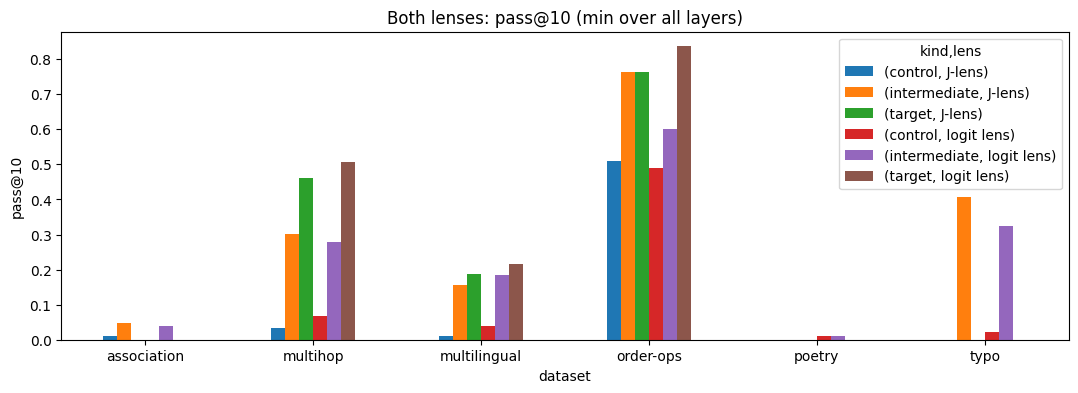

"J-lens − logit lens, inner pass@k",intermediate,control,target
dataset,,,
association,0.010,0.010,NaN
multihop,0.000,-0.047,-0.118
multilingual,-0.028,-0.030,-0.037
order-ops,0.127,-0.020,-0.145
poetry,-0.010,-0.010,NaN
typo,0.083,-0.021,NaN


In [21]:
at_k = scores[scores.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
at_k.plot.bar(figsize=(13, 4), rot=0, title=f"Both lenses: pass@{K} (min over all layers)")
plt.ylabel(f"pass@{K}")
plt.show()

inner_at_k = inner[inner.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
output_at_k = output[output.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
inner_delta = pd.DataFrame({
    kind: inner_at_k[(kind, "J-lens")] - inner_at_k[(kind, "logit lens")]
    for kind in ("intermediate", "control", "target")
})
display(inner_delta.rename_axis(columns="J-lens − logit lens, inner pass@k").round(3))

## 4. At what depth do the words surface?

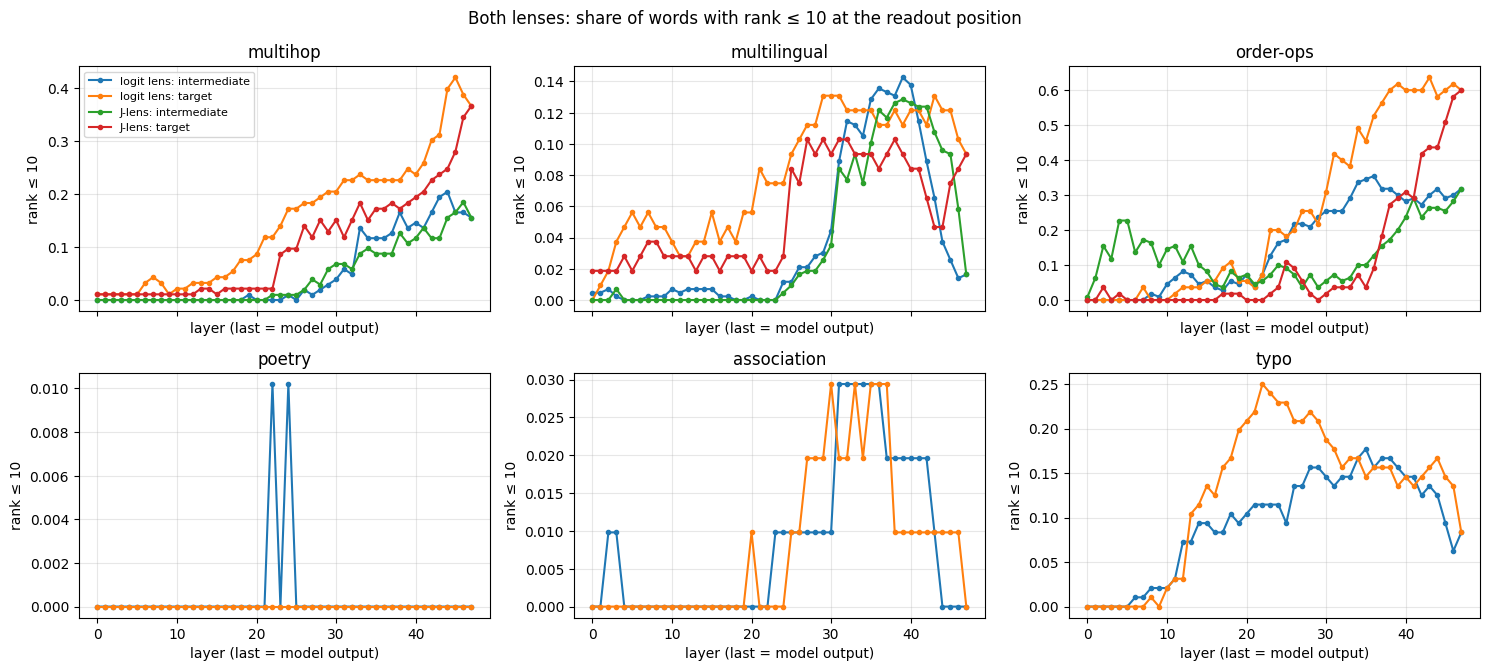

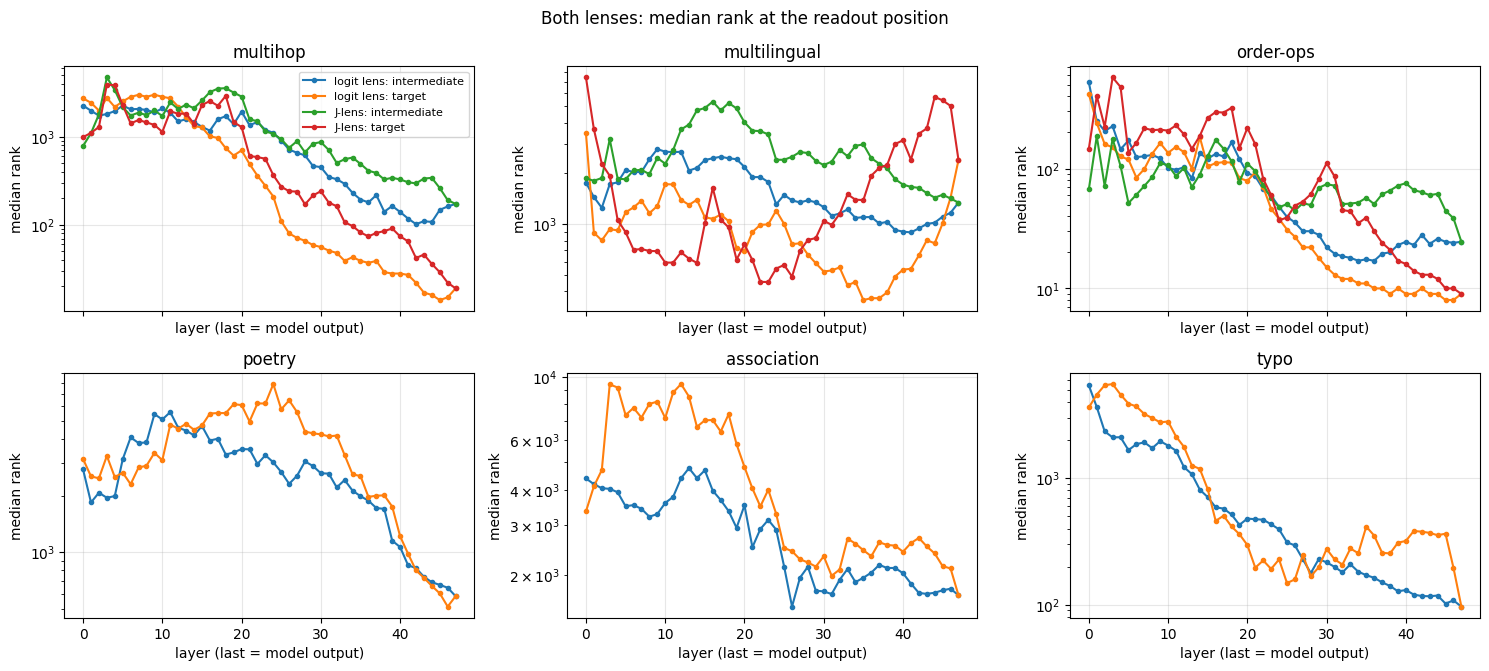

In [38]:
def word_curves(stat):
    return {
        f"{name}: {kind}": stat(words[(words.lens == name) & (words.kind == kind)])
        for name in LENS_NAMES
        for kind in ("intermediate", "target")
    }


plot_layer_curves(
    word_curves(lambda frame: layer_hit_rate(frame, K)),
    title=f"Both lenses: share of words with rank ≤ {K} at the readout position",
    ylabel=f"rank ≤ {K}",
)
plot_layer_curves(
    word_curves(layer_median_rank),
    title="Both lenses: median rank at the readout position",
    ylabel="median rank",
    logy=True,
)

Where the best rank of each intermediate is reached (only words that are hits, rank ≤ K):

In [23]:
(
    inter[inter.best_rank <= K]
    .groupby(["dataset", "lens"]).best_layer.value_counts().unstack(fill_value=0)
    .reindex(columns=range(gpt.n_layers), fill_value=0)
)

best_layer               0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
dataset      lens                                                                                                                                                                                                      
association  J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   1   0   0   1   0   0   1   0   0   0   0   0   1   0   0   0   0   0   0   0   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   1   1   0   0   0   1   0   0   0   0   0   0   0   0   0
multihop     J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   1   0   1   2   0   0   0   0   2   4   0   2   1   0   1   2   3   8
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   1   0   0   0   0   1   0   3   0   1   1   0   1   0   1   4   5   3   1   3
multilingual J-lens       0   0   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   1   1   1   2   6   2   6   0   4   5   4   3   9   6   1   3   3   0   2   1   1
             logit lens   2   0   3   0   0   0   0   0   0   1   1   1   0   2   0   1   0   0   0   0   1   0   0   0   0   0   2   1   5   1   0   8   3   7   1   7   8  12   5   3   3   0   1   0   0   0   0   0
order-ops    J-lens       0   0   1   0   1   7   1   6   2   0   1   4   0   3   0   3   0   0   0   2   0   0   0   2   1   3   1   0   0   1   0   0   1   0   1   1   1   2   0   2   2   5   2   6   2   1   5  14
             logit lens   0   0   0   0   0   0   0   0   0   0   0   2   0   1   0   1   1   0   0   0   2   0   1   2   0   0   1   1   3   3   2   1   2   5   1   5   2   5   4   2   2   2   2   1   1   6   1   4
poetry       logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
typo         J-lens       0   0   0   0   0   0   0   0   0   0   0   1   2   0   3   0   1   0   2   0   3   3   4   1   1   3   0   1   2   0   1   0   0   0   0   0   1   0   2   0   0   1   1   2   1   0   3   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   2   2   1   2   0   1   1   1   1   2   0   0   0   0   1   2   0   1   0   2   1   1   1   1   1   1   1   0   0   0   0   3   0   0   0   2

## 5. How both lenses behave in general

Over all prompt positions (not only the readout one):

* **agreement** — the layer's top-1 equals the model's top-1: how deep the final prediction is formed;
* **copy rate** — the layer's top-1 is the input token at that position: the residual stream still "is" the token embedding
  (GPT-2 ties `wte` and `lm_head`, so an untouched embedding decodes to itself);
* **KL(model ‖ layer)** — how far the layer's distribution is from the output one.

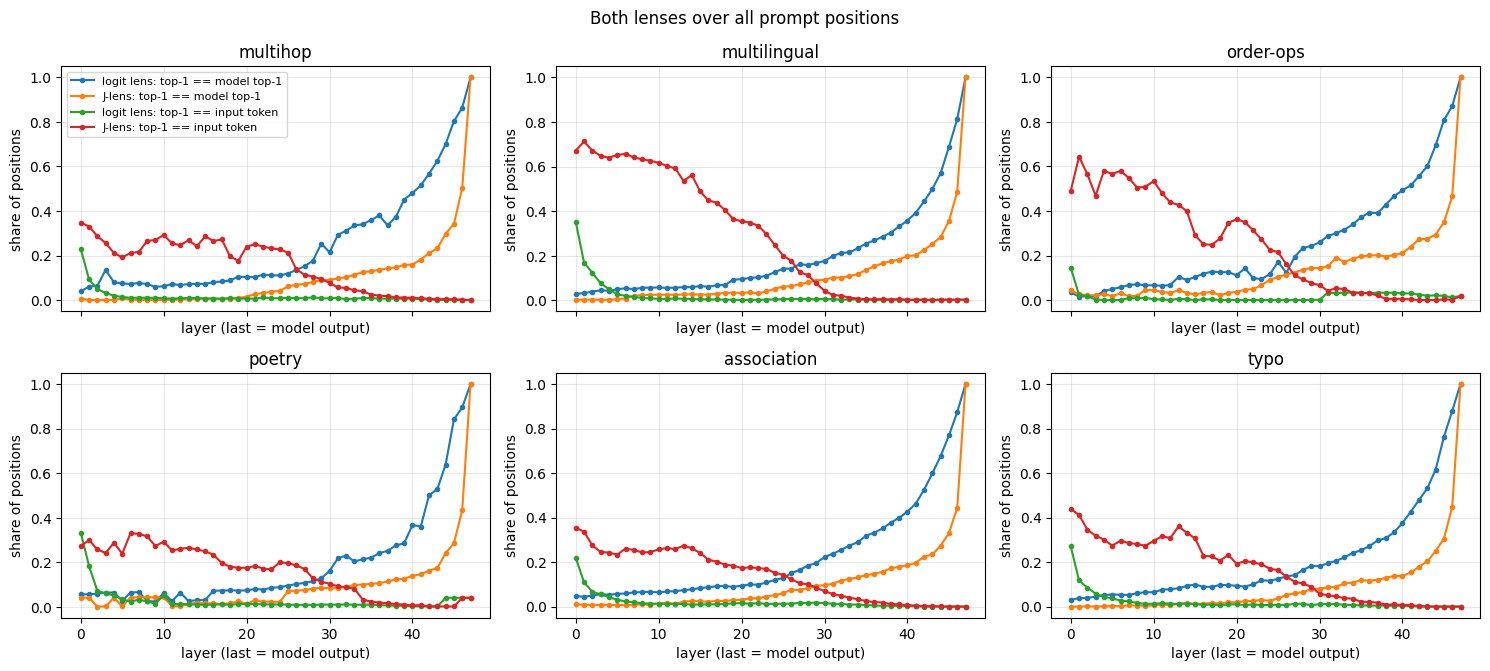

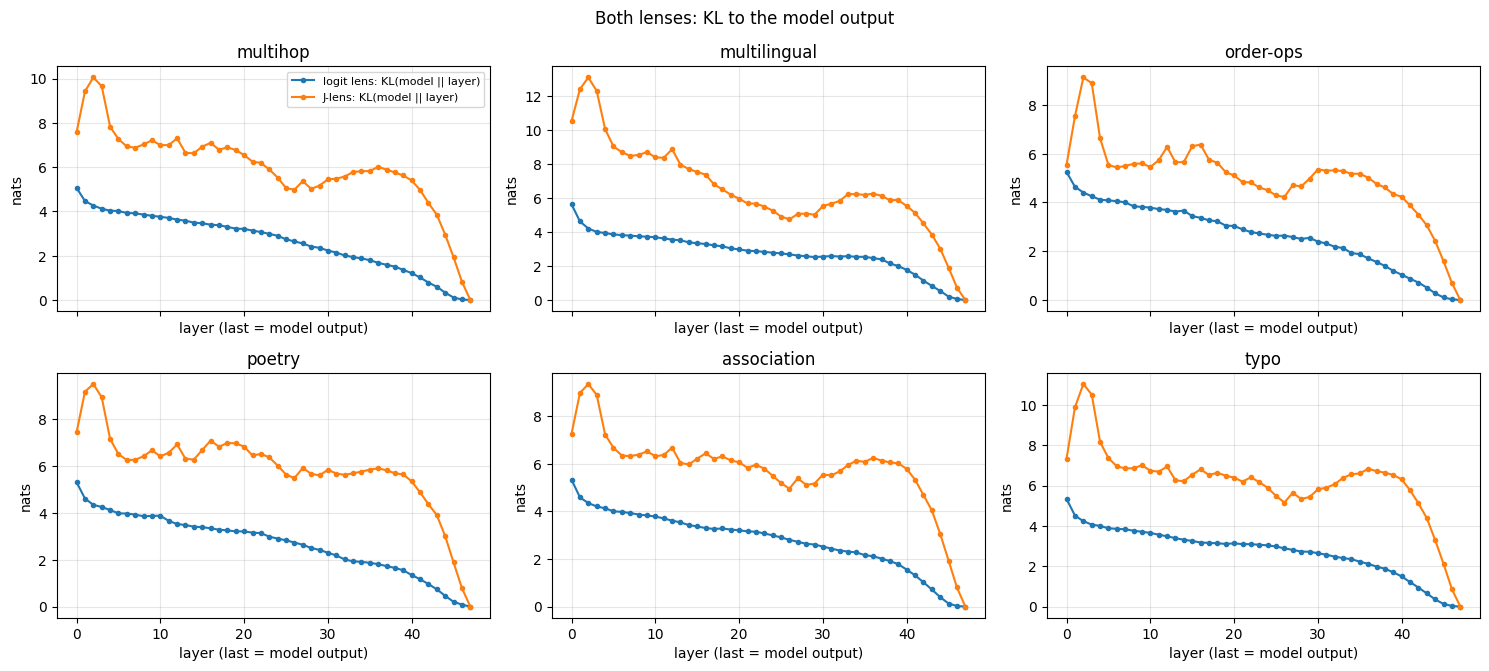

In [24]:
behaviour = {
    name: {column: layer_mean(items[items.lens == name], column)
           for column in ("agreement", "copy_rate", "kl_to_final")}
    for name in LENS_NAMES
}
plot_layer_curves(
    {f"{name}: top-1 == model top-1": behaviour[name]["agreement"] for name in LENS_NAMES}
    | {f"{name}: top-1 == input token": behaviour[name]["copy_rate"] for name in LENS_NAMES},
    title="Both lenses over all prompt positions",
    ylabel="share of positions",
)
plot_layer_curves(
    {f"{name}: KL(model || layer)": behaviour[name]["kl_to_final"] for name in LENS_NAMES},
    title="Both lenses: KL to the model output",
    ylabel="nats",
)

In [25]:
behaviour_rows = []
for name in LENS_NAMES:
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    for dataset in agreement.index:
        behaviour_rows.append({
            "dataset": dataset,
            "lens": name,
            "agreement ≥ 50% from": first_layer(agreement.loc[dataset], 0.5),
            "KL ≤ 1 nat from": first_layer(kl.loc[dataset], 1.0, above=False),
            "copy rate at L0": copy_rate.loc[dataset, 0],
            f"copy rate at L{LAST - 1}": copy_rate.loc[dataset, LAST - 1],
        })
pd.DataFrame(behaviour_rows).set_index(["dataset", "lens"]).unstack("lens").round(3)

agreement ≥ 50% from            KL ≤ 1 nat from            copy rate at L0            copy rate at L46           
lens                       J-lens logit lens          J-lens logit lens          J-lens logit lens           J-lens logit lens
dataset                                                                                                                       
association                    47         42              46         43           0.354      0.219            0.000      0.000
multihop                       46         41              46         42           0.348      0.230            0.002      0.000
multilingual                   47         44              46         43           0.672      0.351            0.002      0.002
order-ops                      47         41              46         41           0.491      0.144            0.001      0.012
poetry                         47         42              46         42           0.272      0.333            0.040      0.040
typo                           47         43              46         42           0.439      0.270            0.000      0.000

## 6. What drives a hit

### 6a. The word is already in the prompt

Early layers of the logit lens decode the input token itself, so a word that is literally in the prompt
(e.g. a number in order-ops) can be a "hit" without any computation.

In [26]:
hits = inter.assign(hit=inter.best_rank <= K, inner_hit=inter.inner_best <= K)
hits.groupby(["dataset", "in_prompt", "lens"]).hit.agg(["mean", "size"]).unstack(["in_prompt", "lens"]).round(3)

mean                                size                             
in_prompt     False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.040      0.030  0.500      0.500  100.0      100.0    2.0        2.0
multihop      0.265      0.245  1.000      1.000  102.0      102.0    1.0        1.0
multilingual  0.157      0.184  0.133      0.200  413.0      413.0   15.0       15.0
order-ops     0.768      0.857  0.759      0.333   56.0       56.0   54.0       54.0
poetry        0.000      0.010    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.411      0.326  0.000      0.000   95.0       95.0    1.0        1.0

### 6b. Single-token words vs words that only have a first-token fallback

In [27]:
hits.groupby(["dataset", "single_token", "lens"]).hit.agg(["mean", "size"]).unstack(["single_token", "lens"]).round(3)

mean                                size                             
single_token  False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.222      0.333  0.032      0.011    9.0        9.0   93.0       93.0
multihop        NaN        NaN  0.272      0.252    NaN        NaN  103.0      103.0
multilingual  0.033      0.100  0.166      0.191   30.0       30.0  398.0      398.0
order-ops       NaN        NaN  0.764      0.600    NaN        NaN  110.0      110.0
poetry          NaN        NaN  0.000      0.010    NaN        NaN   98.0       98.0
typo            NaN        NaN  0.406      0.323    NaN        NaN   96.0       96.0

### 6c. Role of the intermediate

multilingual: `[language, relation, source word, answer in English]`; order-ops: `[intermediate number, operation]`.

In [28]:
roles = hits[hits.dataset.isin(list(ROLE_NAMES))].copy()
roles["role_name"] = [ROLE_NAMES[d][r] for d, r in zip(roles.dataset, roles.role)]
roles.groupby(["dataset", "role_name", "lens"]).agg(
    hit_rate=("hit", "mean"), median_best_rank=("best_rank", "median"), n=("hit", "size"),
    inner_hit_rate=("inner_hit", "mean"), median_inner_rank=("inner_best", "median"),
).unstack("lens").round(3)

hit_rate            median_best_rank                 n            inner_hit_rate            median_inner_rank           
lens                               J-lens logit lens           J-lens logit lens J-lens logit lens         J-lens logit lens            J-lens logit lens
dataset      role_name                                                                                                                                   
multilingual answer (English)       0.065      0.084            512.0      265.0    107        107          0.065      0.084             512.0      265.0
             language               0.439      0.542             14.0        7.0    107        107          0.439      0.542              14.0        7.0
             relation               0.028      0.028            859.0      727.0    107        107          0.028      0.028             859.0      727.0
             source word            0.093      0.084            328.0      209.0    107        107          0.093      0.084             361.0      210.0
order-ops    intermediate number    0.764      0.909              7.0        4.0     55         55          0.727      0.891               7.0        4.0
             operation              0.764      0.291              6.0       19.0     55         55          0.691      0.273               6.0       19.0

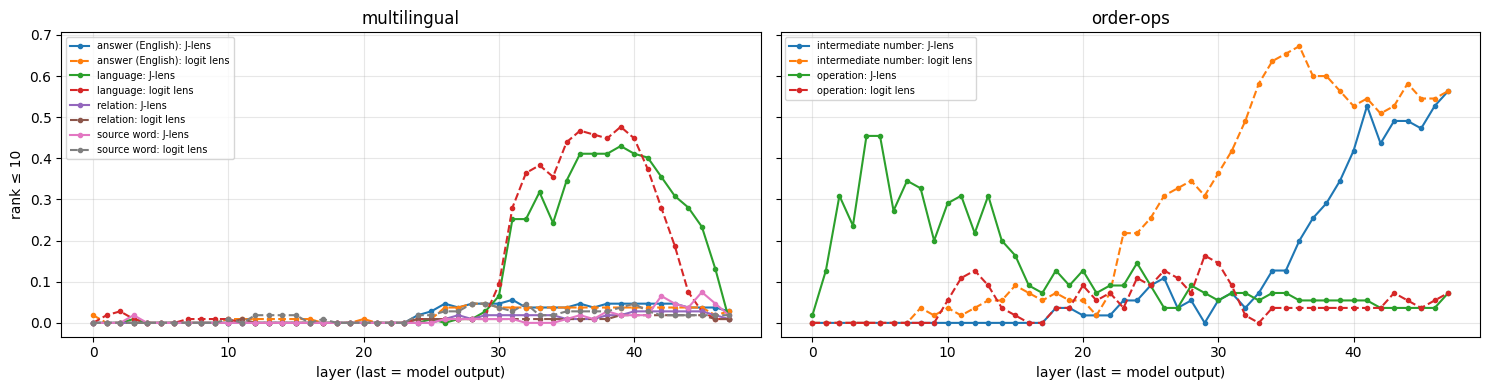

In [29]:
fig, axes = plt.subplots(1, len(ROLE_NAMES), figsize=(15, 4), sharey=True, squeeze=False)
for ax, dataset in zip(axes.flat, ROLE_NAMES):
    group = roles[roles.dataset == dataset]
    for (role, name), role_group in group.groupby(["role_name", "lens"]):
        ax.plot(
            (np.stack(role_group.ranks) <= K).mean(0), marker="o", ms=3,
            label=f"{role}: {name}", linestyle="--" if name == "logit lens" else "-",
        )
    ax.set_title(dataset)
    ax.set_xlabel("layer (last = model output)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
axes.flat[0].set_ylabel(f"rank ≤ {K}")
plt.tight_layout()
plt.show()

### 6d. Does the intermediate show up more often when the model gets the answer right?

In [30]:
correctness = hits.merge(
    with_target[["dataset", "item", "model_correct"]], on=["dataset", "item"], validate="many_to_one"
)
correctness.groupby(["dataset", "model_correct", "lens"]).hit.agg(["mean", "size"]).unstack(["model_correct", "lens"]).round(3)

mean                                size                             
model_correct  False             True              False             True            
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                              
multihop       0.271      0.240  0.286      0.429     96         96      7          7
multilingual   0.160      0.189  0.062      0.062    412        412     16         16
order-ops      0.769      0.602  0.500      0.500    108        108      2          2

## 7. Items: successes and failures

In [31]:
columns = ["dataset", "item", "lens", "word", "best_rank", "best_layer", "inner_best", "inner_best_layer", "in_prompt"]
inter.sort_values("best_rank").groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
4140,typo,typo-water,J-lens,water,1,44,1,44,False
2038,multilingual,fr-time-after-night,logit lens,French,1,33,1,33,False
2047,multilingual,fr-time-after-night,J-lens,French,1,35,1,35,False
2056,multilingual,de-time-after-night,logit lens,German,1,31,1,31,False
4008,typo,typo-family,J-lens,family,1,22,1,22,False
4026,typo,typo-power,logit lens,power,1,33,1,33,False
4028,typo,typo-power,J-lens,power,1,38,1,38,False
2351,multilingual,de-time-old-new,J-lens,German,1,37,1,37,False
1995,multilingual,fr-color-night,J-lens,French,1,39,1,39,False
1986,multilingual,fr-color-night,logit lens,French,1,35,1,35,False


In [32]:
inter.sort_values("best_rank", ascending=False).groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
843,multilingual,turkish-opposite-fast,logit lens,opposite,23568,13,23568,13,False
1359,multilingual,german-phase-water,logit lens,freeze,22323,1,22323,1,False
852,multilingual,turkish-opposite-fast,J-lens,opposite,21471,0,21471,0,False
1422,multilingual,serbian-opposite-day,J-lens,opposite,20900,0,20900,0,False
1341,multilingual,spanish-phase-water,logit lens,freeze,20465,6,20465,6,False
1494,multilingual,irish-opposite-big,J-lens,opposite,17105,7,17105,7,False
3394,association,grief,logit lens,grief,9159,37,9159,37,False
3446,association,beatles,logit lens,Beatles,7132,44,7132,44,False
3148,poetry,couplet-smoke-spoke,J-lens,spoke,6580,5,6580,5,False
3448,association,beatles,J-lens,Beatles,5781,41,5781,41,False


What the lens reads at the readout position, layer by layer (first items of each dataset):

In [33]:
readout = items.groupby(["dataset", "lens"]).head(2).set_index(["dataset", "item", "lens"]).readout_top1.apply(pd.Series)
readout.columns.name = "layer"
readout.sort_index()[shown_layers(gpt.n_layers, LAYER_STRIDE)]

layer                                               0         4         8          12           16          20           24          28          32          36                40           44     47
dataset      item                 lens                                                                                                                                                               
association  grief                J-lens            \n         —      \n\n       \n\n         \n\n        \n\n          She         She         She         She               She          She     \n
                                  logit lens         I         I        He         He           He         She          She         She         She         She               She          She     \n
             pregnant             J-lens                       …      \n\n       \n\n         \n\n         She      herself         She         She         She               She          She     \n
                                  logit lens         I         I        He         He           He         She          She         She         She         She               She          She     \n
multihop     amazon-language      J-lens            \n         —      \n\n       \n\n            ―           —          NOT       slang   languages   languages        Portuguese   Portuguese    not
                                  logit lens       not       not    likely     likely       likely      called   profoundly   identical   bilingual      spoken            called          not    not
             carnival-ocean       J-lens                       '      \n\n       \n\n         Tall           ​      largest     largest     largest     busiest           richest        ocean   most
                                  logit lens      rest      most      same       very         same     largest      largest     largest     largest     largest           largest         most   most
multilingual french-season-summer J-lens             '        -'        -'         -'           -'          -'           -'    MpServer          ét          ét                ét           ét      é
                                  logit lens         €        bl         n       same         same     highest            €          de          ét          ét                ét           ét      é
             spanish-opposite-big J-lens             "         "         "          "           bc          ="      shorter       grand       grand       grand             grand        grand  grand
                                  logit lens         "         K       ign        ign         just        real         tall       grand       grand       grand             grand        grand  grand
order-ops    parens-add-mult      J-lens                       =         =          =            =           =        Total       Total       Total       Total                36           24     24
                                  logit lens  ========  ========  ========   ========         conc           £        Total       Total       Total           8                12           24     24
             parens-sub-mult      J-lens                       =         =   ========            =           =            9           9           9           9                16           16     16
                                  logit lens         0  ========       ===   ========            9           9            9           9           9           9                16           16     16
poetry       couplet-breath-death J-lens             —         —        \n                                                                                                  while        Until    The
                                  logit lens        \n       bra       Ted         ca         Lent                                              And         And               And          The    The
             couplet-stone-bone   J-lens

The most common readout top-1 tokens per layer over all items — generic tokens mean the lens shows no item-specific content there:

In [34]:
top1_tables = {}
for name in LENS_NAMES:
    top1_by_layer = pd.DataFrame(items[items.lens == name].readout_top1.tolist())
    top1_tables[name] = pd.DataFrame({
        "distinct top-1 / items": top1_by_layer.nunique() / len(top1_by_layer),
        "most common": {
            layer: ", ".join(f"{token!r}×{count}" for token, count in column.value_counts().head(5).items())
            for layer, column in top1_by_layer.items()
        },
    }).rename_axis("layer")
pd.concat(top1_tables, axis=1, names=["lens", "metric"])

lens               logit lens                                                                    J-lens                                                   
metric distinct top-1 / items                                        most common distinct top-1 / items                                        most common
layer                                                                                                                                                     
0                    0.237750      '\n'×98, ' "'×93, ' I'×76, ' not'×21, ' 0'×21               0.190563  '\xa0'×166, '"'×79, ' \xad'×62, '\n'×49, ' and...
1                    0.225045  ' I'×97, '"'×78, ' "'×75, ' not'×54, '========...               0.214156  ' —'×137, ' "'×106, ' \xad'×77, ' ='×47, ' and...
2                    0.219601  ' I'×143, ' "'×70, ' not'×58, '"'×47, '=======...               0.210526        ' —'×217, ' "'×96, ' ='×43, ' '×28, " '"×17
3                    0.239564  ' I'×158, ' not'×59, ' "'×47, '========'×45, '...               0.232305     ' —'×106, ' "'×96, "?'"×62, '\xa0'×45, ' …'×32
4                    0.259528  ' I'×100, ' not'×59, '========'×44, '"'×35, '\...               0.219601      ' —'×157, ' "'×96, ' ='×44, ' …'×24, ' --'×18
5                    0.248639  ' I'×88, ' not'×49, '========'×47, ' bra'×42, ...               0.208711     " '"×104, ' "'×93, '\n\n'×79, ' …'×51, ' ='×47
6                    0.292196  ' Maiden'×63, '========'×47, ' I'×41, ' The'×3...               0.212341   '\n\n'×127, ' "'×91, '\n'×83, ' ='×40, ' ...'×31
7                    0.286751  ' It'×49, '========'×46, ' sm'×39, '\n'×39, ' ...               0.214156     '\n\n'×155, '\n'×96, ' "'×87, ' ='×40, ' …'×18
8                    0.279492  ' sm'×56, '========'×44, ' likely'×39, ' It'×3...               0.217786     '\n\n'×169, '\n'×96, ' "'×90, ' ='×26, ' >'×21
9                    0.303085  'WA'×41, '========'×30, ' likely'×29, ' It'×29...               0.232305  '\n\n'×165, ' "'×88, ' Caps'×54, ' Mine'×37, '...
10                   0.313975  ' It'×46, '========'×28, ' te'×26, ' likely'×2...               0.241379  '\n\n'×159, '\xa0'×98, ' "'×92, ' ='×38, ' equ...
11                   0.313975  ' lull'×57, ' It'×42, '========'×32, ' He'×26,...               0.245009  '\n\n'×158, '\xa0'×96, ' "'×88, ' ='×38, ' equ...
12                   0.321234  'ca'×54, ' It'×52, '========'×34, ' lull'×30, ...               0.255898  '\n\n'×152, '\xa0'×97, ' "'×83, ' ='×31, '====...
13                   0.326679  ' It'×55, ' lull'×46, '========'×27, '\xa0'×26...               0.272232  '\n\n'×101, '\xa0'×98, ' ".'×34, ' "'×34, ' ='×30
14                   0.341198  '\xa0'×41, ' It'×40, ' He'×29, ' supposed'×19,...               0.283122   '\xa0'×98, '\n\n'×96, ' "'×59, ' ='×34, ' ".'×19
15                   0.339383  ' te'×85, ' It'×40, '========'×23, ' He'×23, '...               0.286751  '\n\n'×100, '\xa0'×98, ' ."'×31, ' �'×27, ' ='×26
16                   0.373866  ' te'×46, ' He'×28, ' It'×26, '========'×20, '...               0.299456   '\xa0'×98, '\n\n'×91, ' ."'×18, ' ='×17, ' >'×17
17                   0.399274   'Mah'×44, '\xa0'×30, '\n'×26, ' He'×21, ' It'×18               0.292196    '\n\n'×99, '\xa0'×98, '/"'×29, ' >'×22, ' �'×14
18                   0.424682  'Solution'×34, '\xa0'×20, '\n'×20, ' conc'×18,...               0.321234  '\xa0'×94, '\n\n'×87, '/"'×29, ' Puzzle'×28, '...
19                   0.421053  '\xa0'×84, '\n'×12, ' probably'×11, '�'×11, ' ...               0.324864   '\xa0'×99, '\n\n'×63, ' ='×44, ':"'×27, ' ".'×19
20                   0.415608    '\xa0'×78, '\n'×17, ' He'×15, '�'×12, 'real'×11               0.332123  '\xa0'×99, '\n\n'×71, ' ='×45, ':"'×43, ' .......
21                   0.399274  '\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\...               0.362976   '\xa0'×98, '\n\n'×57, ':"'×53, ' ='×45, ' ".'×14
22                   0.402904  '\xa0'×43, '\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\x...               0.388385     '\xa0'×97, ':"'×4

### 7a. Paired inner-layer ranks: which lens improves each intermediate?

One row per intermediate occurrence, aligned by dataset, item, word, and role. A positive
`log10 gain` means J-lens lowers the best inner-layer rank; ties are counted explicitly.

In [35]:
head_to_head = inter.pivot(
    index=["dataset", "item", "word", "role"], columns="lens", values="inner_best"
)
head_to_head["winner"] = np.select(
    [head_to_head["J-lens"] < head_to_head["logit lens"],
     head_to_head["J-lens"] > head_to_head["logit lens"]],
    ["J-lens", "logit lens"], default="tie",
)
head_to_head["log10 gain"] = np.log10(head_to_head["logit lens"]) - np.log10(head_to_head["J-lens"])
paired_summary = head_to_head.groupby("dataset").winner.value_counts().unstack(fill_value=0)
paired_summary = paired_summary.reindex(columns=["J-lens", "logit lens", "tie"], fill_value=0)
paired_summary["median log10 gain"] = head_to_head.groupby("dataset")["log10 gain"].median()
display(paired_summary.round(3))
display(head_to_head.sort_values("log10 gain", ascending=False).head(15))
display(head_to_head.sort_values("log10 gain").head(15))

winner,J-lens,logit lens,tie,median log10 gain
dataset,,,,
association,66,36,0,0.181
multihop,48,46,9,0.000
multilingual,150,250,28,-0.121
order-ops,54,41,15,0.000
poetry,53,45,0,0.056
typo,47,38,11,0.000


lens                                               J-lens  logit lens  winner  log10 gain
dataset      item                  word      role                                        
typo         typo-which            which     0         13        1612  J-lens    2.093422
             typo-another          another   0          1         110  J-lens    2.041393
             typo-different        different 0          1          40  J-lens    1.602060
             typo-because          because   0          3         117  J-lens    1.591065
             typo-within           within    0          3         106  J-lens    1.548185
             typo-until            until     0          2          44  J-lens    1.342423
multilingual bulgarian-color-grass color     1         98        1987  J-lens    1.306972
             de-size-big-small     size      1        137        2717  J-lens    1.297369
order-ops    mod-add               mod       1          1          17  J-lens    1.230449
poetry       couplet-lock-key      key       0         26         440  J-lens    1.228479
order-ops    floordiv-mult         division  1          5          69  J-lens    1.139879
multilingual russian-number-four   number    1        106        1460  J-lens    1.139047
order-ops    floordiv-add          division  1          4          53  J-lens    1.122216
multilingual hungarian-color-sea   color     1        168        2194  J-lens    1.115927
order-ops    parens-add-div        division  1          5          65  J-lens    1.113943

lens                                                  J-lens  logit lens      winner  log10 gain
dataset      item                     word      role                                            
multilingual fr-half-six              six       2        220           1  logit lens   -2.342423
             frn-number-after-one     two       3        165           3  logit lens   -1.740363
             de-size-big-small        small     3        538          13  logit lens   -1.616839
             irish-opposite-big       small     3        475          17  logit lens   -1.446245
             portuguese-season-spring season    1       5021         196  logit lens   -1.408534
poetry       couplet-fight-light      light     0        696          29  logit lens   -1.380211
order-ops    sub-mult-right           12        0         24           1  logit lens   -1.380211
multilingual pt-time-after-night      time      1        972          45  logit lens   -1.334454
             de-place-near-far        far       3        233          11  logit lens   -1.325963
             french-season-summer     summer    2        567          27  logit lens   -1.322219
             bulgarian-color-grass    Bulgarian 0        101           5  logit lens   -1.305351
             spanish-number-three     three     2        301          15  logit lens   -1.302475
             fr-half-six              three     3        193          10  logit lens   -1.285557
poetry       couplet-flight-night     night     0        460          25  logit lens   -1.264818
multilingual es-time-after-day        time      1        311          17  logit lens   -1.262311

## 8. Conclusions

The cell below turns the numbers above into statements, so they stay correct after a re-run
(other seed, other `K`, other model size).

In [36]:
def pct(x):
    return "n/a" if x is None or pd.isna(x) else f"{100 * x:.0f}%"


def layer(x):
    return "never" if x is None else f"L{x}"


def hit_rates(frame, column):
    """Hit rate (best rank <= K) split by a boolean column: {value: (rate, n)}."""
    hit = (frame.best_rank <= K).groupby(frame[column])
    return {value: (rate, n) for value, rate, n in zip(hit.mean().index, hit.mean(), hit.size())}

In [37]:
lines = ["Model accuracy (top-1 == target): " + ", ".join(f"{d} {pct(a)}" for d, a in accuracy.items()) + "."]
for name in LENS_NAMES:
    lines.append(f"--- {name} ---")
    lens_at_k = at_k.xs(name, axis=1, level="lens")
    inner_lens_at_k = inner_at_k.xs(name, axis=1, level="lens")
    output_lens_at_k = output_at_k.xs(name, axis=1, level="lens")
    lens_inter = inter[inter.lens == name]
    inter_curve = layer_hit_rate(lens_inter, K)
    target_curve = layer_hit_rate(target[target.lens == name], K)
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    lens_roles = roles[roles.lens == name]
    lens_correctness = correctness[correctness.lens == name]
    for dataset in lens_at_k.index:
        i, c = lens_at_k.loc[dataset, "intermediate"], lens_at_k.loc[dataset].get("control")
        verdict = "clearly above" if i >= c + 0.1 else "slightly above" if i > c else "NOT above"
        peak = inter_curve.loc[dataset].iloc[:-1]
        lines.append(
            f"{dataset}: intermediates pass@{K} {pct(i)} vs control {pct(c)} — {verdict} chance; "
            f"inner layers alone {pct(inner_lens_at_k.loc[dataset, 'intermediate'])}, model output alone "
            f"{pct(output_lens_at_k.loc[dataset, 'intermediate'])}; best inner layer L{peak.idxmax()} "
            f"({pct(peak.max())} of words at rank ≤ {K})."
        )

    for dataset in target_curve.index:
        curve = target_curve.loc[dataset]
        if curve.iloc[-1] == 0:
            lines.append(f"{dataset}: the target is never in the output top-{K}.")
        else:
            lines.append(
                f"{dataset}: the target is in the output top-{K} for {pct(curve.iloc[-1])} of items "
                f"and reaches half of that by {layer(first_layer(curve, curve.iloc[-1] / 2))}."
            )

    for dataset in agreement.index:
        lines.append(
            f"{dataset}: lens top-1 == model top-1 on ≥50% of positions from {layer(first_layer(agreement.loc[dataset], 0.5))}, "
            f"KL ≤ 1 nat from {layer(first_layer(kl.loc[dataset], 1.0, above=False))}; copy rate "
            f"{pct(copy_rate.loc[dataset, 0])} at L0 → {pct(copy_rate.loc[dataset, LAST - 1])} at L{LAST - 1}."
        )

    for column, yes, no in [
        ("in_prompt", "already in the prompt", "absent from it"),
        ("single_token", "single-token", "first-token fallback"),
    ]:
        rates = hit_rates(lens_inter, column)
        (r_yes, n_yes), (r_no, n_no) = rates.get(True, (None, 0)), rates.get(False, (None, 0))
        lines.append(f"Intermediates {yes}: hit rate {pct(r_yes)} (n={n_yes}) vs {pct(r_no)} (n={n_no}) {no}.")

    for dataset, group in lens_roles.groupby("dataset"):
        by_role = group.groupby("role_name").hit.mean().sort_values(ascending=False)
        lines.append(f"{dataset} by role: " + ", ".join(f"{name} {pct(rate)}" for name, rate in by_role.items()) + ".")

    by_correct = lens_correctness.groupby("model_correct").hit.mean()
    lines.append(
        f"Intermediate hit rate when the model is right: {pct(by_correct.get(True))}, when wrong: {pct(by_correct.get(False))}."
    )


for dataset in inner_at_k.index:
    row = inner_at_k.loc[dataset]
    j, l = row[("intermediate", "J-lens")], row[("intermediate", "logit lens")]
    jc, lc = row[("control", "J-lens")], row[("control", "logit lens")]
    lines.append(
        f"{dataset}: inner-layer pass@{K}, J-lens {pct(j)} vs logit lens {pct(l)} "
        f"(Δ {100 * (j - l):+.1f} pp); margins over control "
        f"{100 * (j - jc):+.1f} pp vs {100 * (l - lc):+.1f} pp."
    )
for dataset, row in paired_summary.iterrows():
    lines.append(
        f"{dataset}: J-lens ranks intermediates higher in {row.get('J-lens', 0):.0f} cases, "
        f"logit lens in {row.get('logit lens', 0):.0f}, ties {row.get('tie', 0):.0f}; "
        f"median log10 rank gain {row['median log10 gain']:+.2f}."
    )
for line in lines:
    print("•", line)

• Model accuracy (top-1 == target): multihop 8%, multilingual 4%, order-ops 2%.
• --- logit lens ---
• association: intermediates pass@10 4% vs control 0% — slightly above chance; inner layers alone 4%, model output alone 0%; best inner layer L31 (3% of words at rank ≤ 10).
• multihop: intermediates pass@10 28% vs control 7% — clearly above chance; inner layers alone 28%, model output alone 17%; best inner layer L44 (20% of words at rank ≤ 10).
• multilingual: intermediates pass@10 18% vs control 4% — clearly above chance; inner layers alone 18%, model output alone 2%; best inner layer L39 (14% of words at rank ≤ 10).
• order-ops: intermediates pass@10 60% vs control 49% — clearly above chance; inner layers alone 58%, model output alone 32%; best inner layer L36 (35% of words at rank ≤ 10).
• poetry: intermediates pass@10 1% vs control 1% — NOT above chance; inner layers alone 1%, model output alone 0%; best inner layer L22 (1% of words at rank ≤ 10).
• typo: intermediates pass@10 32% 

### How to read these numbers

* **Intermediates vs control.** Compare each lens with its control baseline and compare the
  margins between lenses. A larger raw hit rate alone does not establish better intermediate readout.
* **Inner layers vs model output.** Both lenses use the exact same model output. All-layer
  metrics preserve the original analysis; inner-layer pass@k and the paired ranks isolate
  differences in the lens. An inner-layer hit is suggestive, not proof of a reasoning step.
* **Copy rate.** High early-layer copy rates can explain hits for words already in the prompt.
  Compare both lenses' copy curves and the in-prompt split (§6a).
* **Agreement / KL.** Earlier agreement and lower KL describe fidelity to the model output;
  they do not by themselves show that intermediates are exposed better.
* **Model correctness.** Accuracy is measured once per item. The right/wrong split keeps
  both lens measurements attached to that same model answer.
* **Tokenization.** Multi-token words fall back to their first token, which can be generic.
  The single-token split (§6b) retains this diagnostic. Controls share the dataset topic.
* **Fit corpus.** A J-lens depends on its fitting corpus and selected model. Use an independent
  corpus, keep the checkpoint with its model, and vary the mix to test sensitivity.